# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\epsilon\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
(1-\epsilon)\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v} 
    % & \text{negative sign due to integration by parts}
    \\
    -\frac{\mu}{K}\sum_i\left(\int \phi^k\phi^i \, dx \right)v_i&= S \mathbf{v}
\end{aligned}
\end{equation}

For the convection term we have:
\begin{equation}
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
\end{equation}
which we will approximate using a quadrature rule.


Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}+S\mathbf{v}+C^{v}(\mathbf{v},\mathbf{\rho})
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the first term in the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{C}^{\rho_g}(\mathbf{v},\mathbf{\rho})
\end{equation}

The diffusion familiarly becomes:
\begin{equation}
    \mu_\epsilon\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) \rho_i = D_\epsilon \mathbf{\rho}
\end{equation}

The mass transfer term is given by:
\begin{equation}
\begin{aligned}
    \int\phi^k\dot m dx &= \int \phi^k \sum_i \dot m^i(t) \phi^i(x) dx \\
    &= \sum_i \dot m^i(t) \int \phi^k \phi^i dx \\
    &= M_{{\rho_g}} \dot{\mathbf{m}}
\end{aligned}
\end{equation}
where:
\begin{equation}
    \dot{m}^i = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### IMEX Scheme

In [25]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra 

## Definitions

In [26]:
# constants
R = 8.314       # J/(mol*K)     
T = 300.0       # K
C_d = 9.57      # s^-1
p_ref = 1.0e6   # 1MPA
ρ_sat = 7259.0  # kg/m^3
ρ_e = 7165.0    # kg/m^3
E_d = 16473.0   # J/mol
ϵ = 0.4         # unitless, measure of porosity
A_hoffman = 10.57   # unitless
B_hoffman = 3704.6  # K

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_d = C_d * exp(-E_d/(R*T))
p_eqd = p_ref * exp(A_hoffman-B_hoffman/T)

ρ_in = 0.1 * p_eqd / (R * T)

println("A_d = ", A_d, " s^-1")
println("p_eqd = ", p_eqd, " Pa")

A_d = 0.01295997798539817 s^-1
p_eqd = 168863.14809884044 Pa


In [27]:
# Time integration parameters
dt = 1e-4
dt_save = 3.0
T1 = 200.0;

save_every = Int(round(dt_save / dt)) 
nsteps = Int(round(T1 / dt_save))

name = "x. zero dimensional";

## grid

In [28]:
# generates grid
grid = generate_grid(Line, (1,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);


In [29]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [30]:
# constraint handler
ch = ConstraintHandler(dh)
close!(ch)
update!(ch, 0.0)

In [31]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [32]:
struct RHSparams
    A::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_e::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    rhs::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    assemble_mass!::Function    # Complete assembly of the mass matrix, including the nonlinear part
    assemble_rhs!::Function     # Complete assembly of the right-hand side, including the nonlinear part
end

In [33]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )
    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time
    return M
end

assemble_mass! (generic function with 1 method)

In [34]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:

    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A*(params.R*params.T*rhog_q/params.p_eqa-1)*(rhos_q-params.rho_e)
            # for i in 1:length(rhog_local)
            #     ψ = shape_value(params.cellvalues_rhog,q,i)
            #     N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            # end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end



    return N
end

assemble_rhs! (generic function with 1 method)

In [35]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

In [36]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, dh)

# Linear parts of rhs
fill!(rhsL, 0.0)

# Initial condition
apply_analytical!(u, dh, :rho, x -> ρ_in)
apply_analytical!(u, dh, :rho_s, x -> ρ_sat)

# Initial BC application
update!(ch, 0.0)
apply!(u, ch);


In [37]:
params = RHSparams(
    A_d, 
    R, 
    T, 
    p_eqd, 
    ρ_e, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    M,
    ML,
    rhs,
    rhsL,
    assemble_mass!,
    assemble_rhs!    
)

RHSparams(0.01295997798539817, 8.314, 300.0, 168863.14809884044, 7165.0, DofHandler{1, Grid{1, Line, Float64}}(SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}[SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}(DofHandler{1, Grid{1, Line, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1]), [:rho, :rho_s], Interpolation[Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}()], Int64[], 4)], [:rho, :rho_s], [1, 2, 3, 4], [1], [1], true, Grid{1, Line, Float64}(Line[Line((1, 2))], Node{1, Float64}[Node{1, Float64}([0.0]), Node{1, Float64}([1.0])], Dict{String, OrderedCollections.OrderedSet{Int64}}(), Dict{String, OrderedCollections.OrderedSet{Int64}}(), Dict{String, OrderedCollections.OrderedSet{FacetIndex}}("left" => OrderedCollections.OrderedSet{FacetIndex}([FacetIndex((1, 1))]), "right" => OrderedCollections.OrderedSet{FacetIndex}([FacetIndex((1, 2))])), Dict{String, OrderedCollections.OrderedSet{VertexIndex}}()), 4), CellValues{Ferrite.FunctionValues{1, Lag

In [38]:
function res!(res, du, u, params, t)

    params.assemble_mass!(params.M, u, params)
    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    update!(ch, t)
    for k in 1:length(ch.prescribed_dofs)
        dof = ch.prescribed_dofs[k]
        value = ch.inhomogeneities[k]
        res[dof] = u[dof] - value
    end

end

res! (generic function with 1 method)

In [39]:
using DifferentialEquations

In [40]:
update!(ch, 0.0)
apply!(u, ch)          # enforce initial state

dt = 1e-6

params.assemble_rhs!(params.rhs, u, params)
params.assemble_mass!(params.M, u, params)

B = params.rhs * dt + (params.M * u)
A = copy(params.M)
apply!(A, B, ch)

u_new = A \ B
du = ( u_new - u) / dt

4-element Vector{Float64}:
  8.881784197001252e-10
 -8.881784197001252e-10
 -1.8273603927809745
 -1.8273531168233603

In [41]:
rest = zeros(ndofs_total)
res!(rest, du, u, params, 0.0)

println("res = ", sum(rest))

res = 8.468338486000704e-8


In [42]:
differential_vars = trues(length(u))
tspan = (0.0, T1)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(prob, saveat=dt_save, reltol=1e-6, abstol=1e-6)

retcode: Success
Interpolation: 1st order linear
t: 68-element Vector{Float64}:
   0.0
   3.0
   6.0
   9.0
  12.0
  15.0
  18.0
  21.0
  24.0
  27.0
  30.0
  33.0
  36.0
   ⋮
 168.0
 171.0
 174.0
 177.0
 180.0
 183.0
 186.0
 189.0
 192.0
 195.0
 198.0
 200.0
u: 68-element Vector{Vector{Float64}}:
 [6.770232864198558, 6.770232864198558, 7259.0, 7259.0]
 [6.770232864198558, 6.770232864198558, 7253.674154887031, 7253.674154887031]
 [6.770232864198558, 6.770232864198558, 7248.64777459167, 7248.64777459167]
 [6.770232864198558, 6.770232864198558, 7243.9048113549725, 7243.9048113549725]
 [6.770232864198558, 6.770232864198558, 7239.430803846642, 7239.430803846642]
 [6.770232864198558, 6.770232864198558, 7235.210194731411, 7235.210194731411]
 [6.770232864198558, 6.770232864198558, 7231.228649309147, 7231.228649309147]
 [6.770232864198558, 6.770232864198558, 7227.474501215701, 7227.474501215701]
 [6.770232864198558, 6.770232864198558, 7223.935392728471, 7223.935392728471]
 [6.770232864198558, 

## Plotting/animating

In [43]:
using Plots

In [44]:
# sol_ρ_s_constant_gas = sol_ρ_s

In [45]:
U = Array(sol);

In [47]:
foldername = name

U = Array(sol)

sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρgmax = maximum(sol_ρ)
ρsmax = maximum(sol_ρ_s)
ρmax = maximum([ρgmax, ρsmax])
ρmin = minimum(sol_ρ)


6.770232864198558

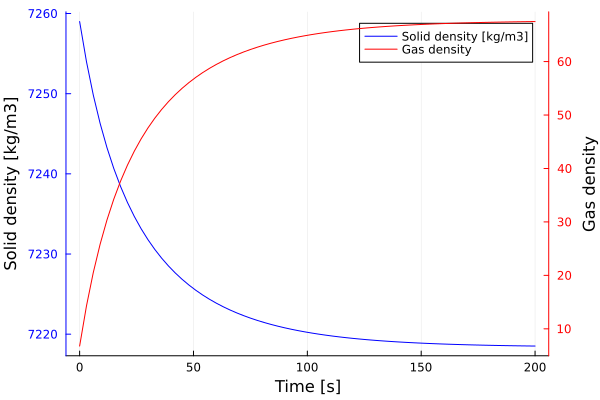

In [24]:
p = plot(
    discrete_t,
    sol_ρ_s[1, :],
    label="Solid density [kg/m3]",
    xlabel="Time [s]",
    ylabel="Solid density [kg/m3]",
    color=:blue,
    y_foreground_color_text=:blue,
    y_foreground_color_axis=:blue,
    y_foreground_color_border=:blue,
)

# Actual data on the right axis, but no legend entry
plot!(
    twinx(),
    discrete_t,
    sol_ρ[1, :],
    color = :red,
    y_foreground_color_text=:red,
    y_foreground_color_axis=:red,
    y_foreground_color_border=:red,
    ylabel = "Gas density",
    label = false,
)

# Dummy series for the legend
plot!(
    p,
    [NaN], [NaN],
    color = :red,
    label = "Gas density",
)

In [82]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_variable_gas_desorption.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_variable_gas_desorption.png"

In [ ]:
# sol_ρ_s_constant_gas = sol_ρ_s

2×68 Matrix{Float64}:
 7259.0  7253.67  7248.65  7243.9  …  7167.25  7167.12  7167.0  7166.93
 7259.0  7253.67  7248.65  7243.9     7167.25  7167.12  7167.0  7166.93

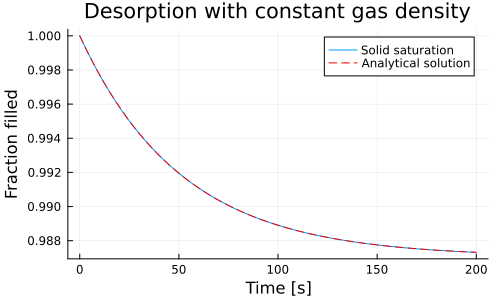

In [50]:
# Plot 1: Constant gas density
p1 = plot(
    discrete_t,
    sol_ρ_s_constant_gas[1, :] ./ ρ_sat,
    xlabel = "Time [s]",
    ylabel = "Fraction filled",
    label = "Solid saturation",
    title = "Desorption with constant gas density",
    size = (500, 300),
    legend = :topright
)

k = A_d * (ρ_in * R * T / p_eqd - 1) / (1 - ϵ)
fill_fraction_analytical = [
    ρ_e - (ρ_e - ρ_sat) * exp(k * t) for t in discrete_t
]

plot!(
    p1,
    discrete_t,
    fill_fraction_analytical ./ ρ_sat,
    label = "Analytical solution",
    color = :red,
    linestyle = :dash,
)

In [51]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_constant_gas_desorption.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_constant_gas_desorption.png"

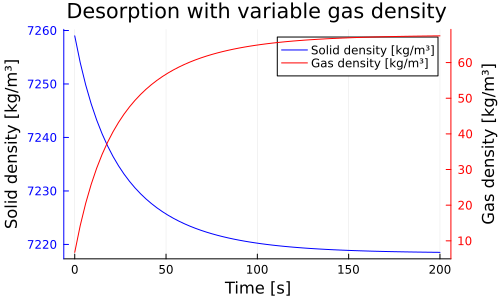

In [26]:
# Plot 2: Variable gas density
p2 = plot(
    discrete_t,
    sol_ρ_s[1, :],
    label = "Solid density [kg/m³]",
    xlabel = "Time [s]",
    ylabel = "Solid density [kg/m³]",
    title = "Desorption with variable gas density",
    color = :blue,
    y_foreground_color_text = :blue,
    y_foreground_color_axis = :blue,
    y_foreground_color_border = :blue,
    size = (500, 300)
)

plot!(
    twinx(),
    discrete_t,
    sol_ρ[1, :],
    color = :red,
    ylabel = "Gas density [kg/m³]",
    label = false,
    y_foreground_color_text = :red,
    y_foreground_color_axis = :red,
    y_foreground_color_border = :red,
)

# Dummy legend entry
plot!(
    p2,
    [NaN], [NaN],
    color = :red,
    label = "Gas density [kg/m³]",
)


In [86]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_1_variable_gas_desorption.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_1_variable_gas_desorption.png"

In [200]:
println("ρ_e = ", ρ_e, ", ρ_sat = ", ρ_sat)

ρ_e = 7165.0, ρ_sat = 7259.0


In [ ]:
sol_ρ_s[1, 1]

7177.193471664117

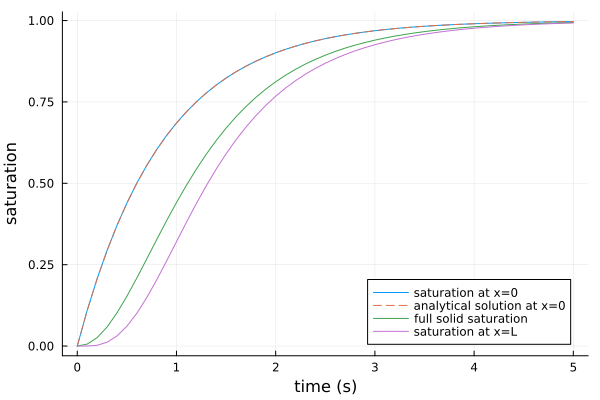

In [97]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [172]:
savefig(joinpath(foldername, "fill_fraction.png"))

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\e. differential equations implemetations\\fill_fraction.png"

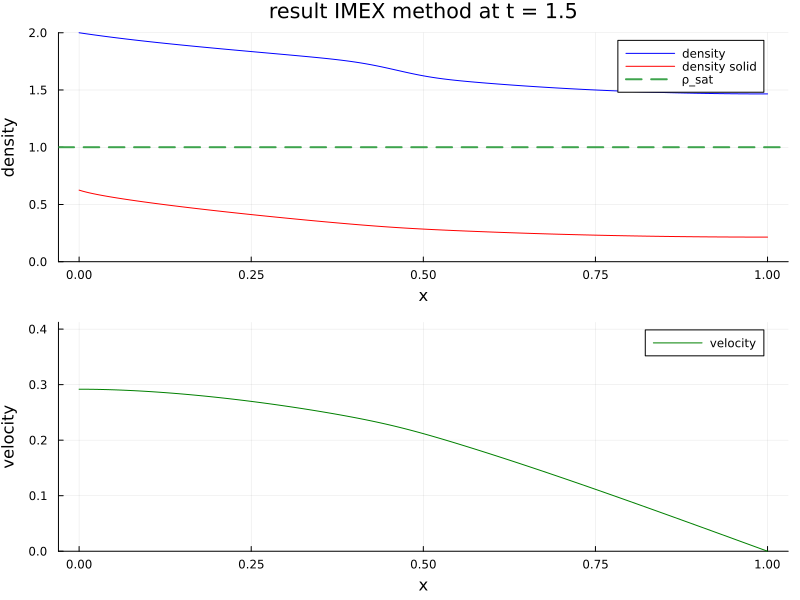

In [22]:
k = 15

# top plot: density + total pressure
p1 = plot(
    discrete_x,
    sol_ρ[:, k],
    label="density",
    color=:blue,
    xlabel="x",
    ylabel="density",
    title="result IMEX method at t = $(round(discrete_t[k], digits=3))",
    ylims=(0, ρmax),
    legend=:topright
)

plot!(
    p1,
    discrete_x,
    sol_ρ_s[:, k],
    label="density solid",
    color=:red,
)

p2 = plot(
    discrete_x,
    sol_v[:, k],
    label="velocity",
    color=:green,
    xlabel="x",
    ylabel="velocity",
    ylims=(vmin, vmax),
    legend=:topright
)

hline!(p1, 
    [rho_sat],
    label = "ρ_sat",
    lw = 2,
    # color = :green,
    linestyle = :dash)

plot(p1, p2, layout=(2,1), size=(800,600))

In [23]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_4_result_IMEX.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_4_result_IMEX.png"

### Ugly plots below

# Debugging

In [ ]:
# debugging
doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

In [18]:
# debugging
display(Matrix(M_rho[rho_global, rho_global]))
display(Matrix(D[v_global, v_global]))
display(Matrix(P[
    v_global ,
    rho_global
    ]))
display(Matrix(M_v[v_global, v_global]))

201×201 Matrix{Float64}:
 0.00166667   0.000833333  0.0          …  0.0          0.0
 0.000833333  0.00333333   0.000833333     0.0          0.0
 0.0          0.000833333  0.00333333      0.0          0.0
 0.0          0.0          0.000833333     0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 ⋮                                      ⋱               ⋮
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0

201×201 Matrix{Float64}:
 -200.0   200.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
  200.0  -400.0   200.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0   200.0  -400.0   200.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0   200.0  -400.0   200.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0   200.0  -400.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0   200.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0


201×201 Matrix{Float64}:
 5.0  -5.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 5.0   0.0  -5.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   5.0  -8.88178e-16  -5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   5.0           8.88178e-16      0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0         

201×201 Matrix{Float64}:
 0.00333333  0.00166667  0.0         …  0.0         0.0         0.0
 0.00166667  0.00666666  0.00166666     0.0         0.0         0.0
 0.0         0.00166666  0.00666664     0.0         0.0         0.0
 0.0         0.0         0.00166666     0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 ⋮                                   ⋱                          ⋮
 0.0         0.0         

In [ ]:
# debugging

# --------------------------------------------------
# Assemble constant matrices
# --------------------------------------------------
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

A_lin = -P - D + M_rho/dt
B_lin = M_rho/dt

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
ndofs_total = ndofs(dh)

u   = zeros(ndofs_total)
rhs = zeros(ndofs_total)
N   = zeros(ndofs_total)

apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

update!(ch, 0.0)
apply!(u, ch)

println("Initial u:")
display(u)

# --------------------------------------------------
# Assemble nonlinear pieces at IC
# --------------------------------------------------
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v,
              facetvalues, left, dh)

println("||N|| = ", norm(N))

# --------------------------------------------------
# Build system
# --------------------------------------------------
A = copy(A_lin)
B = copy(B_lin)

A .+= M_v/dt
B .+= M_v/dt

rhs .= B*u + N

println("norm(rhs) = ", norm(rhs))

# --------------------------------------------------
# Apply BCs
# --------------------------------------------------
update!(ch, dt)

rhsdata = get_rhs_data(ch, A)

A_bc   = copy(A)
rhs_bc = copy(rhs)

apply!(A_bc, ch)
apply_rhs!(rhsdata, rhs_bc, ch)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
println("size(A) = ", size(A_bc))
println("rank estimate = ", rank(Matrix(A_bc)))

println("minimum diag(A) = ", minimum(diag(A_bc)))
println("maximum diag(A) = ", maximum(diag(A_bc)))

# --------------------------------------------------
# Solve ONE timestep
# --------------------------------------------------
u_new = A_bc \ rhs_bc

apply!(u_new, ch)

println("max |u_new-u| = ", maximum(abs.(u_new .- u)))

# --------------------------------------------------
# Check fields separately
# --------------------------------------------------
println("rho old:")
display(u[rho_global])

println("rho new:")
display(u_new[rho_global])

println("v old:")
display(u[v_global])

println("v new:")
display(u_new[v_global])